In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matlab.engine

In [3]:
# Pre-processing steps for the VAE dataset
# This is step 1, where I am only preparing the data frame to be suitable for the VAE model.

# Data preprocessing for VAE model

# Load data
df = pd.read_csv("input_VAE.csv", header=0, usecols=range(34))

# 只有存在HFtype列时才做类型转换
if 'HFtype' in df.columns:
    df['HFtype'] = df['HFtype'].astype('category').cat.codes + 1

# Convert boolean columns to integer
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

# Remove columns with >20% missing values
missing_threshold = 0.2
missing_fraction = df.isnull().mean()
cols_to_drop_missing = missing_fraction[missing_fraction > missing_threshold].index.tolist()
df = df.drop(columns=cols_to_drop_missing)
print(f"Columns dropped due to missingness >20%: {cols_to_drop_missing}")

# Remove columns with constant values
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
df = df.drop(columns=constant_cols)
print(f"Columns dropped due to constant value: {constant_cols}")

# Remove duplicate columns
df_T = df.T.drop_duplicates()
df = df_T.T
print("Shape after removing duplicate columns:", df.shape)

for col in df.columns:
    df[col] = df[col].apply(lambda x: np.log10(x) if pd.notnull(x) and x > 0 else np.nan)

# Impute missing values using KNN (k=5)
cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values to be imputed: {cols_with_missing}")
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
if cols_with_missing:
    print(f"Imputed columns: {cols_with_missing}")
else:
    print("No columns required imputation.")

# 对连续变量反变换回原始空间
df_imputed = df_imputed.apply(lambda x: np.power(10, x))
df = df_imputed
# Round columns with <=5 unique整数值（忽略缺失）且全为整数/小数的列
rounded_cols = []
for col in df.columns:
    # 只对数值型列处理
    if pd.api.types.is_numeric_dtype(df[col]):
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) <= 10:
            # 自定义分界：小数部分<0.25向下取整，>=0.25向上到0.5，>=0.75进到下一个整数，最小值为1
            vals = np.maximum(df_imputed[col], 1)
            frac = vals - np.floor(vals)
            new_vals = np.where(frac < 0.25, np.floor(vals),
                np.where(frac < 0.75, np.floor(vals) + 0.5, np.ceil(vals)))
            df_imputed[col] = new_vals
            rounded_cols.append(col)

if rounded_cols:
    print(f"Rounded columns with <=10 unique values: {rounded_cols}")
else:
    print("No columns met the <=10 unique value threshold for rounding.")


# One-hot encode multiclass categorical variables
multi_cats = []
for col in ["HFtype"]:
    if col in df.columns:
        multi_cats.append(col)
if multi_cats:
    df = pd.get_dummies(df, columns=multi_cats, drop_first=False)

# Convert one-hot back to index for true labels
hftype_cols = [col for col in df.columns if col.startswith("HFtype_")]
if hftype_cols:
    df["HFtype_index"] = df[hftype_cols].values.argmax(axis=1)
    # Drop the one-hot columns from input
    df = df.drop(columns=hftype_cols)

Columns dropped due to missingness >20%: []
Columns dropped due to constant value: []
Shape after removing duplicate columns: (177, 34)
Columns with missing values to be imputed: []
No columns required imputation.
Rounded columns with <=10 unique values: ['Sex']


In [4]:
# Pre-processing steps for the VAE dataset
# This is step 2, where I separate continuous and categorical variables and check the normality of the continuous variables.

# Categorical: columns with few unique values (e.g., <=10) or all values are integers and unique count is small.
# Continuous: columns with many unique values or float type and not binary-like.

categorical_cols = []
continuous_cols = []
unique_threshold = 10  # You can adjust this threshold as needed

for col in df.columns:
    n_unique = df[col].nunique(dropna=True)
    col_dtype = df[col].dtype
    # Heuristic: treat as categorical if unique values are small and all values are integers
    if n_unique <= unique_threshold:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)


# Will also need column indices instead of names to create tensors later:
categorical_col_indices = [df.columns.get_loc(c) for c in categorical_cols]
continuous_col_indices = [df.columns.get_loc(c) for c in continuous_cols]

# print("正态性检验（Shapiro-Wilk）结果：")
# for col in continuous_cols:
#     col_name = df.columns[col] if isinstance(col, int) else col
#     data_col = df[col_name].dropna()
#     if len(data_col) < 3:
#         print(f"{col_name}: 数据量太少，无法检验")
#         continue
#     stat, p = shapiro(data_col)
#     if p < 0.05:
#         result = "非正态 (p < 0.05)"
#     else:
#         result = "正态 (p >= 0.05)"
#     print(f"{col_name}: p = {p:.4f} -> {result}")
#     # Q-Q图
#     plt.figure(figsize=(4, 4))
#     stats.probplot(data_col, dist="norm", plot=plt)
#     plt.title(f"{col_name} Q-Q Plot")
#     plt.tight_layout()
#     plt.show()
    
## 06/10 comment: most of the continuous variables are not normally distributed, I don't know how many effects this will cause and I will try to keep unchanged first.
# Log-transform continuous variables to reduce skewness
# 只显示有小于等于0的列和数量
problem_cols = (df[continuous_cols] <= 0).sum()
problem_cols = problem_cols[problem_cols > 0]
if not problem_cols.empty:
    print("以下列存在小于等于0的值：")
    print(problem_cols)
else:
    print("所有连续变量都大于0，可以安全做log10变换。")
# 如果都为0，说明安全
df[continuous_cols] = df[continuous_cols].apply(lambda x: np.log10(x))


continuous_dims = len(continuous_cols)
categorical_dims = [
    df[col].nunique() for col in categorical_cols
]

所有连续变量都大于0，可以安全做log10变换。


In [5]:
# Get tensor for the VAE model

df["Sex"] = df["Sex"].replace({2: 0, 1: 1})

# Select data rows and columns
data = df.iloc[:,:].copy()

# Min-Max Scale continuous columns only
scaler = MinMaxScaler()
data.loc[:, continuous_cols] = scaler.fit_transform(data.loc[:, continuous_cols])

# Convert to torch.Tensor
X_train = torch.tensor(data.values, dtype=torch.float32)

print(X_train.shape)

torch.Size([177, 34])


In [9]:
# Define the AutoEncoder model for VAE
input_size = 34  # Total input features (continuous + categorical)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Set the number of hidden units
        self.num_hidden = 16
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, self.num_hidden),
            nn.ReLU(),
        )
        
        # Decoder shared layers
        self.fc1 = nn.Linear(self.num_hidden, 256)
        self.fc2 = nn.Linear(256, 128)
        
        # Separate heads
        self.fc_continuous = nn.Linear(128, continuous_dims)
        self.fc_categoricals = nn.ModuleList([
            nn.Linear(128, cat_dim) for cat_dim in categorical_dims
        ])
        
    def forward(self, x, temperature=0.5):
        # Encode
        encoded = self.encoder(x)
        
        # Decode
        h = F.relu(self.fc1(encoded))
        h = F.relu(self.fc2(h))
        
        out_continuous = self.fc_continuous(h)
        
        out_categoricals = []
        for fc in self.fc_categoricals:
            logits = fc(h)
            out_categoricals.append(logits)
        return encoded, out_continuous, out_categoricals
    
class VAE(AutoEncoder):
    def __init__(self):
        super().__init__()
        # Add mu and log_var layers for reparameterization
        self.mu_layer = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var_layer = nn.Linear(self.num_hidden, self.num_hidden)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, temperature=0.5):
        # Encode
        encoded = self.encoder(x)
        
        # Get mu and log_var
        mu = self.mu_layer(encoded)
        log_var = self.log_var_layer(encoded)
        
        # Sample latent vector z
        z = self.reparameterize(mu, log_var)
        
        # Decode
        h = F.relu(self.fc1(z))
        h = F.relu(self.fc2(h))
        
        out_continuous = self.fc_continuous(h)
        
        out_categoricals = []
        for fc in self.fc_categoricals:
            logits = fc(h)
            out_categoricals.append(logits)    
        return z, out_continuous, out_categoricals, mu, log_var

    def sample(self, num_samples, temperature=0.5):
        with torch.no_grad():
            # Sample random z
            z = torch.randn(num_samples, self.num_hidden).to(device)
            
            # Decode
            h = F.relu(self.fc1(z))
            h = F.relu(self.fc2(h))
            
            samples_continuous = self.fc_continuous(h)
            
            samples_categoricals = []
            for fc in self.fc_categoricals:
                logits = fc(h)
                soft_sample = F.gumbel_softmax(logits, tau=temperature, hard=True)  # hard=True for discrete output
                samples_categoricals.append(soft_sample)
            
        return samples_continuous, samples_categoricals
    

def vae_kl_loss(mu, log_var):
    return -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / mu.size(0)

def autoencoder_loss(recon_continuous, true_continuous,
                     recon_categoricals, true_categoricals,
                     kl_loss, kl_weight=1e-5):
    # Continuous part
    mse_loss = F.mse_loss(recon_continuous, true_continuous, reduction='mean')
    
    # Categorical part
    cat_loss = 0
    for recon_cat, true_cat in zip(recon_categoricals, true_categoricals):
        # true_cat is [N] long tensor (category index)
        cat_loss += F.cross_entropy(recon_cat, true_cat, reduction='mean')
    cat_loss /= len(recon_categoricals)  # optional: balance contribution
    
    # Total
    total_loss = mse_loss + cat_loss + kl_weight * kl_loss
    return total_loss


In [10]:
torch.set_num_threads(4)

def train_vae(X_continuous, X_categoricals, learning_rate=3e-4, num_epochs=10000, batch_size=4, kl_weight=5e-7):
    model = VAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)

    train_dataset = torch.utils.data.TensorDataset(
        X_continuous,
        *X_categoricals  # Unpack the list of categorical features
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    recon_losses = []
    kl_losses = []
    total_losses = []

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        
        for batch in train_loader:
            batch_continuous = batch[0]  # first element
            batch_categoricals = list(batch[1:])  # the rest

            batch_continuous = batch_continuous.to(device)
            batch_categoricals = [b.to(device) for b in batch_categoricals]

            # 拼接输入：categorical 变量需要 unsqueeze(1) 再 float()
            input_batch = torch.cat(
                [batch_continuous] + [b.unsqueeze(1).float() for b in batch_categoricals],
                dim=1
            )
            # input_batch = torch.cat(
            # [batch_continuous] +
            # [b.unsqueeze(1).float() for b in batch_categoricals[:-1]] +  # 正常 one-hot 展开过的
            # [F.one_hot(b.squeeze(), num_classes=3).float() for b in batch_categoricals[-1:]],  # index → one-hot
            # dim=1
            # )


            encoded, recon_continuous, recon_categoricals, mu, log_var = model(input_batch, temperature=0.5)

            # KL Divergence
            kl = vae_kl_loss(mu, log_var)

            # Loss
            loss = autoencoder_loss(
                recon_continuous, batch_continuous,
                recon_categoricals, batch_categoricals,
                kl_loss=kl, kl_weight=kl_weight
            )

            # 统计recon和kl
            mse_loss = F.mse_loss(recon_continuous, batch_continuous, reduction='mean')
            cat_loss = 0
            for recon_cat, true_cat in zip(recon_categoricals, batch_categoricals):
                cat_loss += F.cross_entropy(recon_cat, true_cat, reduction='mean')
            cat_loss /= len(recon_categoricals)
            recon_loss = mse_loss + cat_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * batch_continuous.size(0)
            total_recon += recon_loss.item() * batch_continuous.size(0)
            total_kl += kl.item() * batch_continuous.size(0)

        epoch_loss = total_loss / len(train_loader.dataset)
        epoch_recon = total_recon / len(train_loader.dataset)
        epoch_kl = total_kl / len(train_loader.dataset)
        total_losses.append(epoch_loss)
        recon_losses.append(epoch_recon)
        kl_losses.append(epoch_kl)
        print(f"Epoch {epoch+1}/{num_epochs} — Total: {epoch_loss:.4f} | Recon: {epoch_recon:.4f} | KL: {kl_weight * epoch_kl:.4f}")

        if epoch_loss < 8e-5:
            print("Early stopping.")
            break

    # 训练结束后返回各项loss
    return model, total_losses, recon_losses, kl_losses


In [11]:
#eng = matlab.engine.start_matlab()
#eng.addpath(r'C:\Users\WHL\Documents\GitHub\Mat\TriSeg-Digital-Twins', nargout=0)

# Assume full input X_train_full (scaled already)
X_continuous = X_train[:,continuous_col_indices]  # continuous features
X_categoricals = [
    X_train[:, col_idx].long() for col_idx in categorical_col_indices
]  # list of tensors, each of shape: [408]

# Now you can train
model, total_losses, recon_losses, kl_losses = train_vae(X_continuous, X_categoricals)

Epoch 1/10000 — Total: 0.9490 | Recon: 0.9490 | KL: 0.0000
Epoch 2/10000 — Total: 0.7708 | Recon: 0.7708 | KL: 0.0000
Epoch 3/10000 — Total: 0.7387 | Recon: 0.7387 | KL: 0.0000
Epoch 4/10000 — Total: 0.7209 | Recon: 0.7209 | KL: 0.0000
Epoch 5/10000 — Total: 0.6347 | Recon: 0.6347 | KL: 0.0000
Epoch 6/10000 — Total: 0.3605 | Recon: 0.3605 | KL: 0.0000
Epoch 7/10000 — Total: 0.1264 | Recon: 0.1264 | KL: 0.0000
Epoch 8/10000 — Total: 0.0740 | Recon: 0.0740 | KL: 0.0000
Epoch 9/10000 — Total: 0.0629 | Recon: 0.0629 | KL: 0.0000
Epoch 10/10000 — Total: 0.0588 | Recon: 0.0588 | KL: 0.0000
Epoch 11/10000 — Total: 0.0526 | Recon: 0.0526 | KL: 0.0000
Epoch 12/10000 — Total: 0.0533 | Recon: 0.0533 | KL: 0.0000
Epoch 13/10000 — Total: 0.0524 | Recon: 0.0524 | KL: 0.0000
Epoch 14/10000 — Total: 0.0505 | Recon: 0.0505 | KL: 0.0000
Epoch 15/10000 — Total: 0.0508 | Recon: 0.0508 | KL: 0.0000
Epoch 16/10000 — Total: 0.0505 | Recon: 0.0505 | KL: 0.0000
Epoch 17/10000 — Total: 0.0509 | Recon: 0.0509 | 

In [12]:
# 用训练集输入VAE，查看重建效果
model.eval()
with torch.no_grad():
    # 构造输入：连续+分类
    input_batch = torch.cat(
        [X_train[:, continuous_col_indices]] +
        [X_train[:, col_idx].unsqueeze(1).float() for col_idx in categorical_col_indices],  # 其他分类变量
        dim=1
    ).to(device)  # <-- 确保输入在同一设备

    # 前向传播
    z, recon_continuous, recon_categoricals, mu, log_var = model(input_batch)
    # 分类输出取argmax
    recon_categorical_indices = [torch.argmax(logits, dim=1) for logits in recon_categoricals]
    # 还原数据
    recon_columns = []
    cont_idx = 0
    cat_idx = 0
    for col_idx in range(X_train.shape[1]):
        if col_idx in categorical_col_indices:
            recon_columns.append(recon_categorical_indices[cat_idx].unsqueeze(1))
            cat_idx += 1
        else:
            recon_columns.append(recon_continuous[:, cont_idx].unsqueeze(1))
            cont_idx += 1
    recon_tensor = torch.cat(recon_columns, dim=1)
    recon_np = recon_tensor.cpu().numpy()
    # 反归一化连续变量
    recon_np_original = recon_np.copy()
    recon_np_original[:, continuous_col_indices] = scaler.inverse_transform(recon_np[:, continuous_col_indices])

    max_log10 = 4.816  # 或你认为合理的最大log10值
    no_clip_cols = ['k_pas_LV', 'k_pas_RV', 'k_act_LV', 'k_act_RV'] 
    clip_cols = [col for col in continuous_cols if col not in no_clip_cols]
    clip_col_indices = [df.columns.get_loc(col) for col in clip_cols]
    no_clip_col_indices = [df.columns.get_loc(col) for col in no_clip_cols]

    # DataFrame写法
    df_clip = recon_np_original.copy()
    for idx in clip_col_indices:
        recon_np_original[:, idx] = np.power(10, np.clip(recon_np_original[:, idx], None, max_log10))
    for idx in no_clip_col_indices:
        recon_np_original[:, idx] = np.power(10, recon_np_original[:, idx])

    # 同步对原始df的连续变量做反log10变换
    if isinstance(df, pd.DataFrame):
        df_original = df.copy()
        df_original.iloc[:, continuous_col_indices] = np.power(10, df.iloc[:, continuous_col_indices])
        print("df_original已恢复为原始物理量级")
    else:
        print("df 不是DataFrame，无法反log10变换")

    df_original["Sex"] = df_original["Sex"].replace({2: 0, 1: 1})
    # 保存或查看
    df_recon = pd.DataFrame(recon_np_original, columns=df.columns)
    df_recon.to_csv("vae_reconstruction_on_train.csv", index=False)
    print("重建数据已保存为 vae_reconstruction_on_train.csv")
    df_recon.head()

df_original已恢复为原始物理量级
重建数据已保存为 vae_reconstruction_on_train.csv


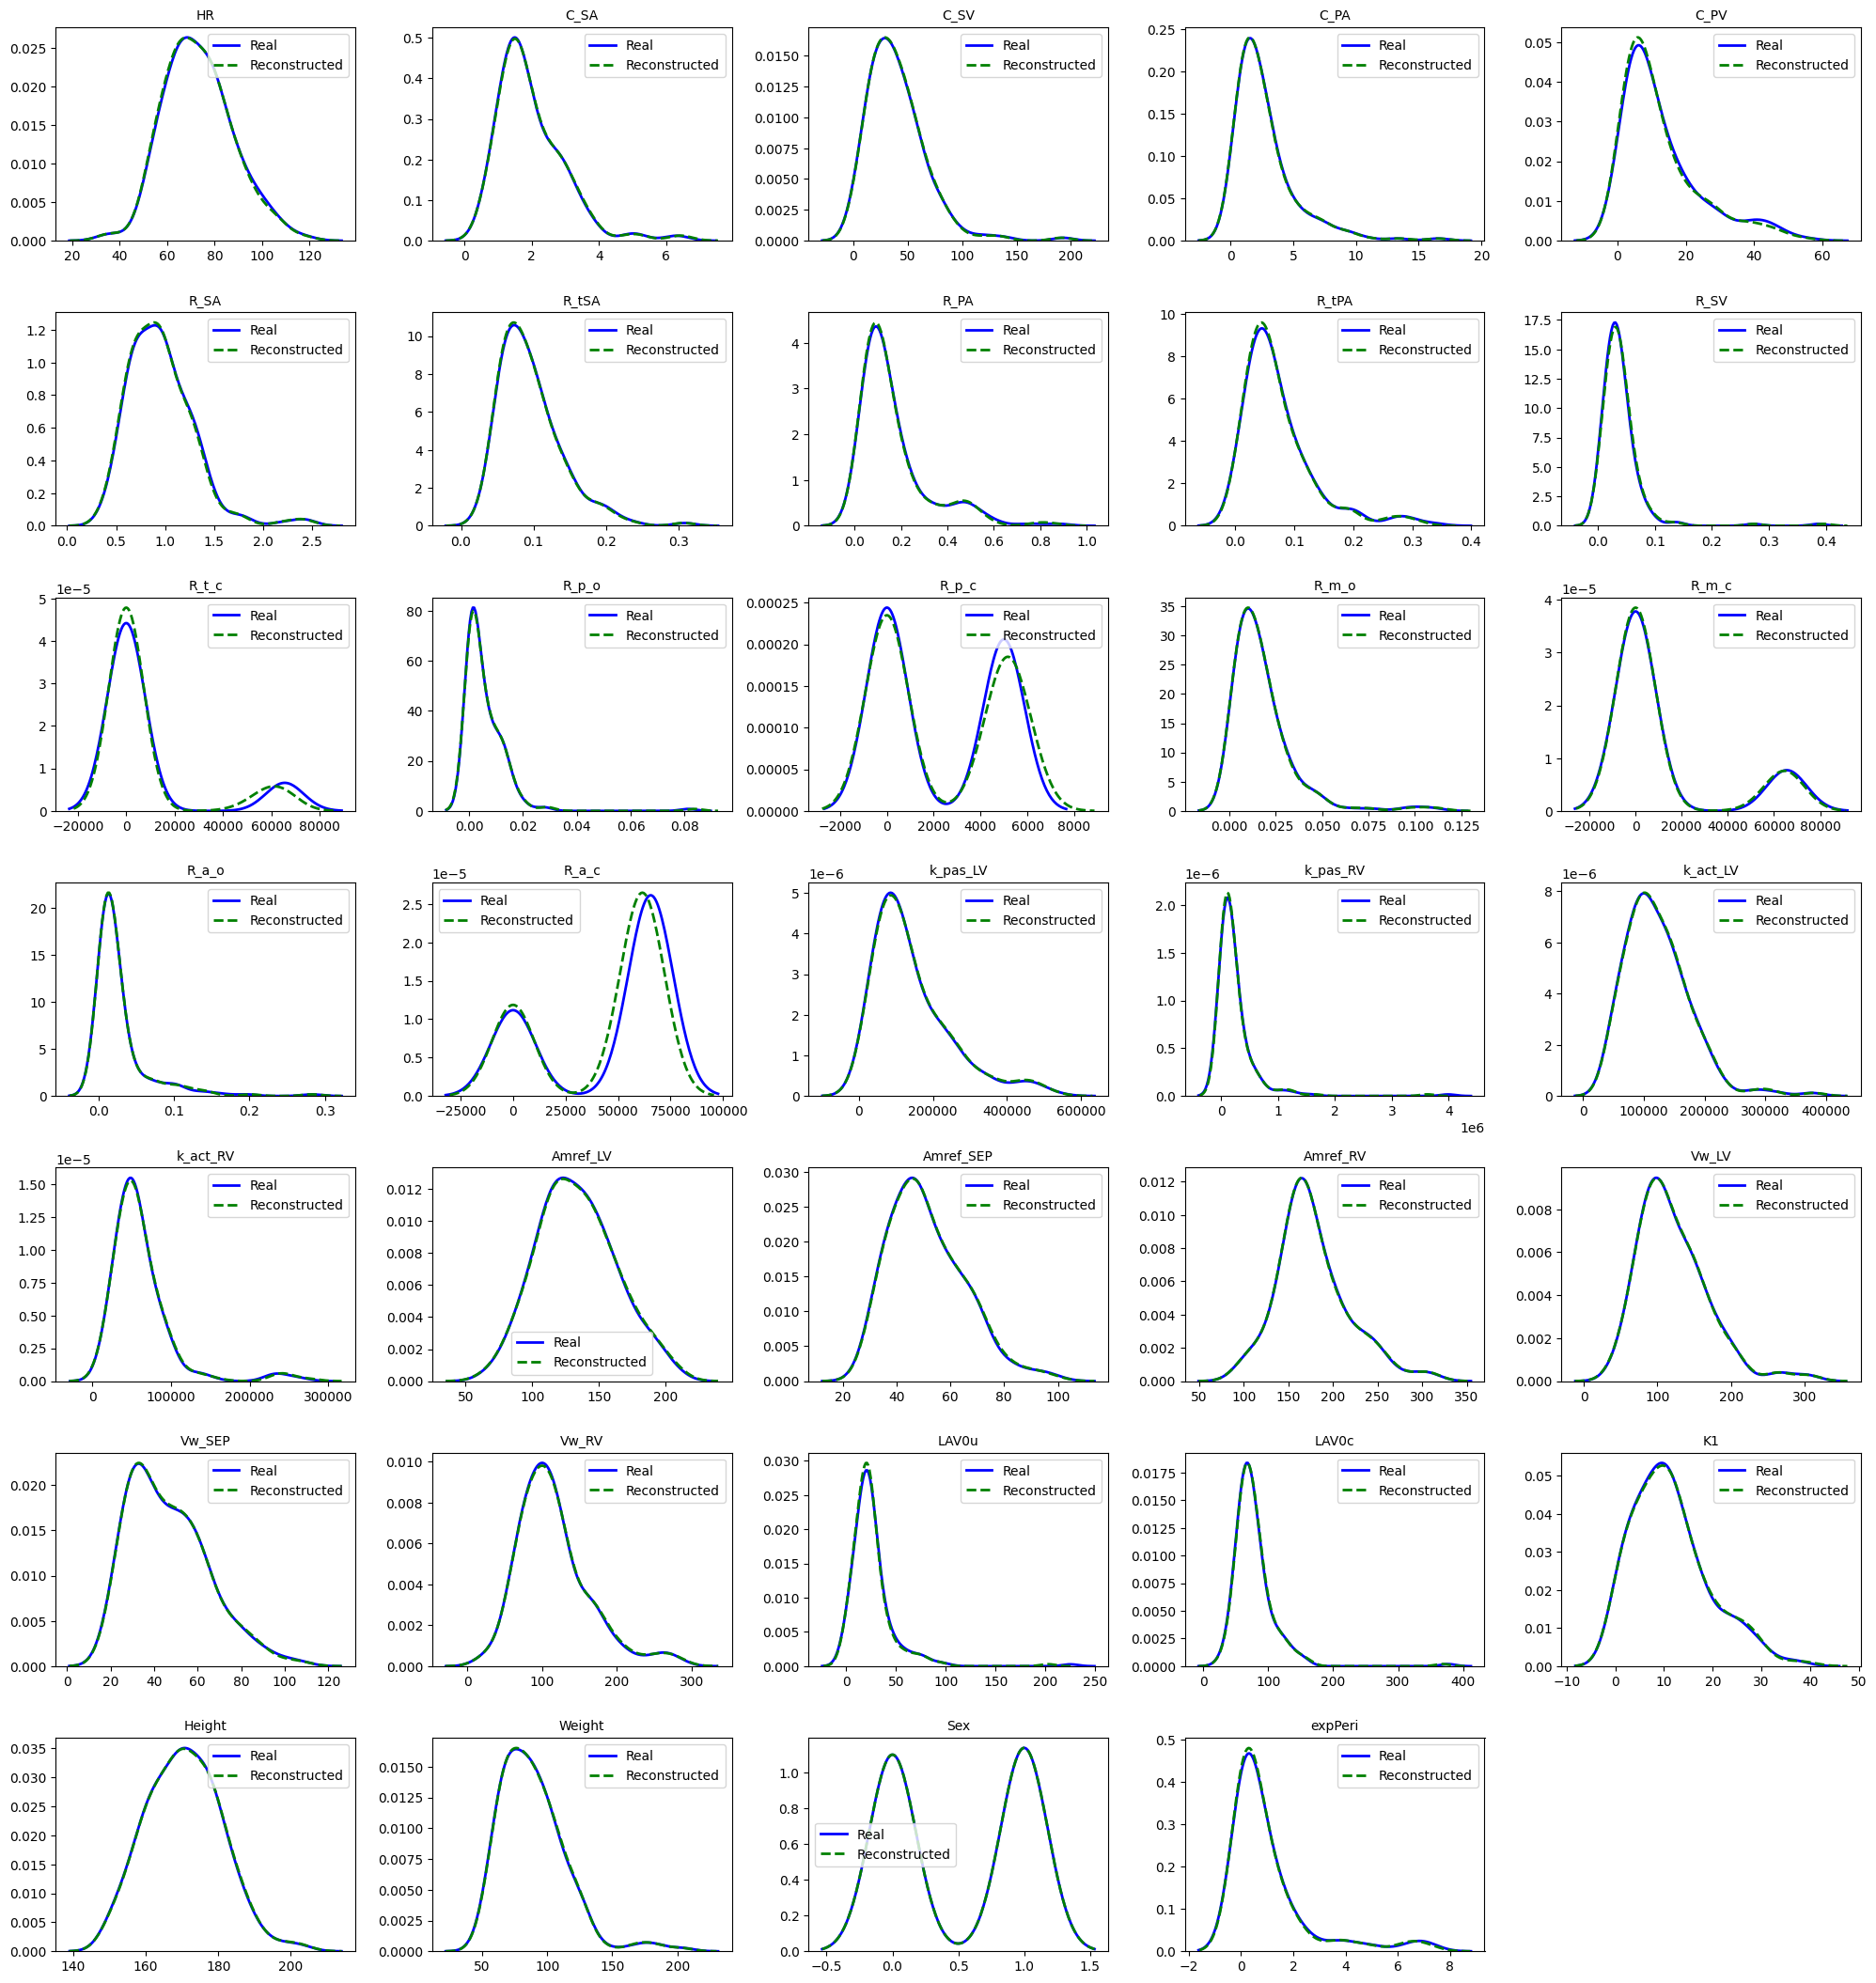

In [ ]:
# 读取重建数据
recon_data = pd.read_csv("vae_reconstruction_on_train.csv")

# 只画前35个变量
num_cols = 35
cols_to_plot = df_original.columns[:num_cols]

fig, axes = plt.subplots(nrows=num_cols // 5 + 1, ncols=5, figsize=(20, 3 * (num_cols // 5 + 1)))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.kdeplot(df_original[col], ax=axes[i], label="Real", color="blue", linewidth=2)
    sns.kdeplot(recon_data[col], ax=axes[i], label="Reconstructed", color="green", linestyle="--", linewidth=2)
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("VAE_reconstruction_PDF_CC.png", dpi=300, bbox_inches='tight')
plt.show()

潜在空间维度: (177, 16)
Z向量统计信息:
  均值: [-0.11250547  0.02247351  0.05801216  0.15117398  0.11156625  0.08407009
 -0.01133765 -0.23338163  0.15816092 -0.09225635  0.0902575   0.34451172
 -0.70465785  0.2939688   0.28055766  0.15035413]
  标准差: [0.4309214  0.4271822  0.3619803  0.3243914  0.2000117  0.23070446
 0.33366126 0.4482471  0.38750476 0.48945886 0.47817904 0.35879004
 0.36149395 0.507522   0.5082087  0.49953145]
  最小值: [-1.0704699  -0.95268106 -0.9264856  -0.6192293  -0.34390965 -0.42805013
 -0.79813534 -1.554824   -0.81232375 -1.1991643  -1.1538354  -0.549221
 -1.668735   -1.0888078  -0.9700546  -1.0834161 ]
  最大值: [0.87283444 0.9901652  1.0225878  1.0386204  0.71675175 0.70917386
 0.8437156  0.7337028  1.2372391  0.89947337 1.2320569  1.2234353
 0.12354273 1.6935894  1.6497427  1.3850132 ]


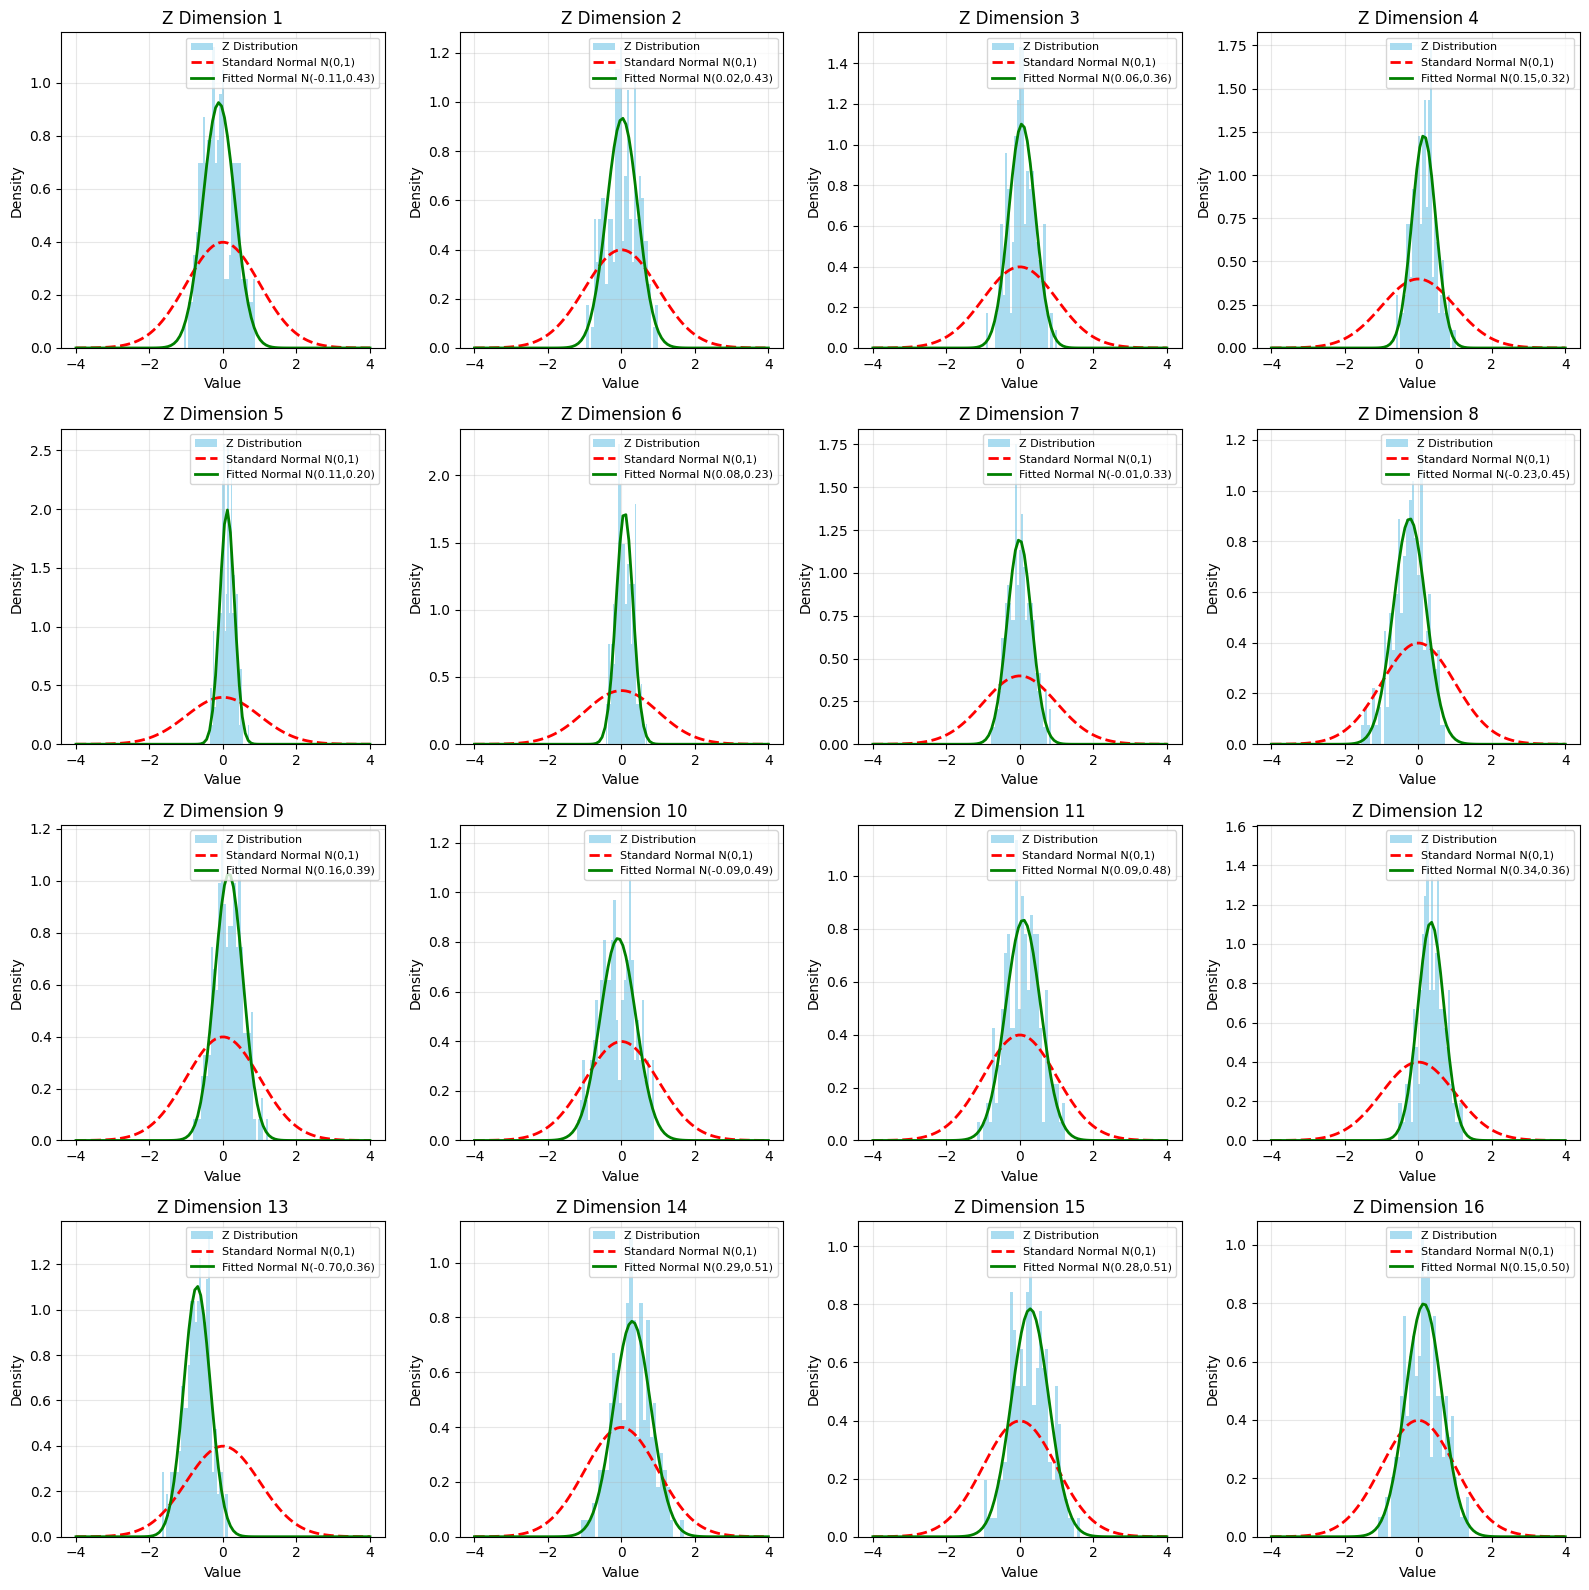

In [13]:
# 分析潜在空间Z向量的分布
model.eval()
with torch.no_grad():
    # 构造输入：连续+分类
    input_batch = torch.cat(
        [X_train[:, continuous_col_indices]] +
        [X_train[:, col_idx].unsqueeze(1).float() for col_idx in categorical_col_indices],
        dim=1
    ).to(device)

    # 前向传播获取潜在向量
    z, recon_continuous, recon_categoricals, mu, log_var = model(input_batch)
    
    # 将Z向量转换为numpy数组用于分析
    z_vectors = z.cpu().numpy()
    mu_vectors = mu.cpu().numpy()
    log_var_vectors = log_var.cpu().numpy()
    
    print(f"潜在空间维度: {z_vectors.shape}")
    print(f"Z向量统计信息:")
    print(f"  均值: {np.mean(z_vectors, axis=0)}")
    print(f"  标准差: {np.std(z_vectors, axis=0)}")
    print(f"  最小值: {np.min(z_vectors, axis=0)}")
    print(f"  最大值: {np.max(z_vectors, axis=0)}")

# 可视化Z向量的分布
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i in range(min(16, z_vectors.shape[1])):  # 显示前16个维度
    ax = axes[i]
    
    # 绘制直方图和KDE
    ax.hist(z_vectors[:, i], bins=30, density=True, alpha=0.7, color='skyblue', label='Z Distribution')
    
    # 绘制理论正态分布（标准正态分布N(0,1)）
    x_range = np.linspace(-4, 4, 100)
    theoretical_normal = stats.norm.pdf(x_range, 0, 1)
    ax.plot(x_range, theoretical_normal, 'r--', linewidth=2, label='Standard Normal N(0,1)')
    
    # 绘制拟合正态分布
    mu_fitted, std_fitted = stats.norm.fit(z_vectors[:, i])
    fitted_normal = stats.norm.pdf(x_range, mu_fitted, std_fitted)
    ax.plot(x_range, fitted_normal, 'g-', linewidth=2, label=f'Fitted Normal N({mu_fitted:.2f},{std_fitted:.2f})')
    
    ax.set_title(f'Z Dimension {i+1}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# 移除多余的子图
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("VAE_Latent_Space_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# 正态性检验和更详细的统计分析
from scipy.stats import shapiro, anderson, kstest

print("="*60)
print("Latent Space Z Vector Normality Test")
print("="*60)

normality_results = []
for i in range(z_vectors.shape[1]):
    z_dim = z_vectors[:, i]
    
    # Shapiro-Wilk检验（样本数<5000时推荐）
    if len(z_dim) <= 5000:
        shapiro_stat, shapiro_p = shapiro(z_dim)
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
    
    # Kolmogorov-Smirnov检验（与标准正态分布比较）
    ks_stat, ks_p = kstest(z_dim, 'norm', args=(np.mean(z_dim), np.std(z_dim)))
    
    # Anderson-Darling检验
    ad_result = anderson(z_dim, dist='norm')
    ad_stat = ad_result.statistic
    ad_critical = ad_result.critical_values[2]  # 5%显著性水平
    ad_is_normal = ad_stat < ad_critical
    
    results = {
        'dimension': i+1,
        'mean': np.mean(z_dim),
        'std': np.std(z_dim),
        'shapiro_stat': shapiro_stat,
        'shapiro_p': shapiro_p,
        'shapiro_normal': shapiro_p > 0.05 if not np.isnan(shapiro_p) else None,
        'ks_stat': ks_stat,
        'ks_p': ks_p,
        'ks_normal': ks_p > 0.05,
        'ad_stat': ad_stat,
        'ad_critical': ad_critical,
        'ad_normal': ad_is_normal
    }
    normality_results.append(results)
    
    print(f"Dimension {i+1:2d}: Mean={np.mean(z_dim):6.3f}, Std={np.std(z_dim):6.3f}")
    if not np.isnan(shapiro_p):
        print(f"         Shapiro-Wilk: p={shapiro_p:.4f} ({'Normal' if shapiro_p > 0.05 else 'Non-normal'})")
    print(f"         Kolmogorov-Smirnov: p={ks_p:.4f} ({'Normal' if ks_p > 0.05 else 'Non-normal'})")
    print(f"         Anderson-Darling: Stat={ad_stat:.4f}, Critical={ad_critical:.4f} ({'Normal' if ad_is_normal else 'Non-normal'})")
    print()

# 统计正态性检验结果
total_dims = len(normality_results)
ks_normal_count = sum([r['ks_normal'] for r in normality_results])
ad_normal_count = sum([r['ad_normal'] for r in normality_results])

print("="*60)
print("Normality Test Summary:")
print(f"Total dimensions: {total_dims}")
print(f"KS test passed normality: {ks_normal_count}/{total_dims} ({ks_normal_count/total_dims*100:.1f}%)")
print(f"AD test passed normality: {ad_normal_count}/{total_dims} ({ad_normal_count/total_dims*100:.1f}%)")

if not np.isnan(normality_results[0]['shapiro_p']):
    shapiro_normal_count = sum([r['shapiro_normal'] for r in normality_results if r['shapiro_normal'] is not None])
    print(f"Shapiro test passed normality: {shapiro_normal_count}/{total_dims} ({shapiro_normal_count/total_dims*100:.1f}%)")
print("="*60)

Latent Space Z Vector Normality Test
Dimension  1: Mean=-0.113, Std= 0.431
         Shapiro-Wilk: p=0.0073 (Non-normal)
         Kolmogorov-Smirnov: p=0.4728 (Normal)
         Anderson-Darling: Stat=1.2205, Critical=0.7700 (Non-normal)

Dimension  2: Mean= 0.022, Std= 0.427
         Shapiro-Wilk: p=0.0652 (Normal)
         Kolmogorov-Smirnov: p=0.5897 (Normal)
         Anderson-Darling: Stat=0.6578, Critical=0.7700 (Normal)

Dimension  3: Mean= 0.058, Std= 0.362
         Shapiro-Wilk: p=0.6914 (Normal)
         Kolmogorov-Smirnov: p=0.8646 (Normal)
         Anderson-Darling: Stat=0.3465, Critical=0.7700 (Normal)

Dimension  4: Mean= 0.151, Std= 0.324
         Shapiro-Wilk: p=0.7832 (Normal)
         Kolmogorov-Smirnov: p=0.9208 (Normal)
         Anderson-Darling: Stat=0.2257, Critical=0.7700 (Normal)

Dimension  5: Mean= 0.112, Std= 0.200
         Shapiro-Wilk: p=0.6564 (Normal)
         Kolmogorov-Smirnov: p=0.9082 (Normal)
         Anderson-Darling: Stat=0.2389, Critical=0.7700 (Norm

训练集Z向量相关矩阵:
相关矩阵形状: (16, 16)
相关矩阵统计信息:
  最大相关系数: 0.6971
  最小相关系数: -0.8308
  平均绝对相关系数: 0.2521


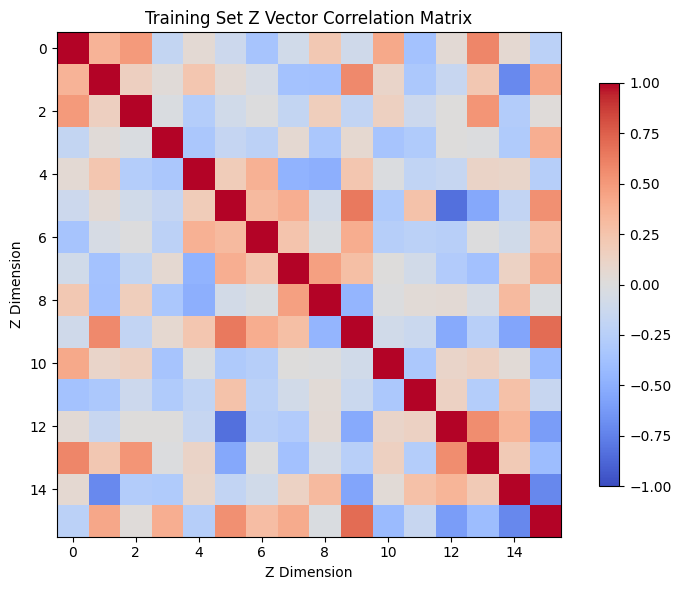


强相关维度对 (|r| > 0.5):
Z维度 1 vs Z维度 14: r = 0.5887
Z维度 2 vs Z维度 10: r = 0.5734
Z维度 2 vs Z维度 15: r = -0.7077
Z维度 3 vs Z维度 14: r = 0.5189
Z维度 6 vs Z维度 10: r = 0.6422
Z维度 6 vs Z维度 13: r = -0.8308
Z维度 6 vs Z维度 14: r = -0.5438
Z维度 6 vs Z维度 16: r = 0.5394
Z维度 10 vs Z维度 13: r = -0.5276
Z维度 10 vs Z维度 15: r = -0.5549
Z维度 10 vs Z维度 16: r = 0.6971
Z维度 13 vs Z维度 14: r = 0.5601
Z维度 13 vs Z维度 16: r = -0.6052
Z维度 15 vs Z维度 16: r = -0.7125

总结:
- Z向量维度: 16
- 强相关对数量: 14
- 相关矩阵已保存为: VAE_Latent_Space_Correlation.png


In [20]:
# 分析训练集Z向量的相关矩阵
# 计算Z向量的相关矩阵
correlation_matrix = np.corrcoef(z_vectors.T)

print("训练集Z向量相关矩阵:")
print(f"相关矩阵形状: {correlation_matrix.shape}")
print(f"相关矩阵统计信息:")
print(f"  最大相关系数: {np.max(correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]):.4f}")
print(f"  最小相关系数: {np.min(correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]):.4f}")
print(f"  平均绝对相关系数: {np.mean(np.abs(correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)])):.4f}")

plt.figure(figsize=(8, 6))  # 设置图像大小

# 热力图: 完整相关矩阵
im = plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Training Set Z Vector Correlation Matrix')
plt.xlabel('Z Dimension')
plt.ylabel('Z Dimension')

# 添加颜色条
plt.colorbar(im, shrink=0.8)

# 调整布局并显示
plt.tight_layout()
plt.show()

# 分析强相关对
print("\n强相关维度对 (|r| > 0.5):")
strong_corr_pairs = []
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[1]):
        corr_val = correlation_matrix[i, j]
        if abs(corr_val) > 0.5:
            strong_corr_pairs.append((i+1, j+1, corr_val))
            print(f"Z维度 {i+1} vs Z维度 {j+1}: r = {corr_val:.4f}")

if not strong_corr_pairs:
    print("没有发现强相关维度对 (|r| > 0.5)")

print(f"\n总结:")
print(f"- Z向量维度: {correlation_matrix.shape[0]}")
print(f"- 强相关对数量: {len(strong_corr_pairs)}")
print(f"- 相关矩阵已保存为: VAE_Latent_Space_Correlation.png")

In [22]:
# 相关性感知采样方法（保留相关结构，标准化方差）

def sample_with_covariance(model, num_samples, temperature=0.5, standardize_variance=True):
    """
    使用训练集Z向量的经验分布进行采样
    
    Parameters:
    - model: 训练好的VAE模型
    - num_samples: 生成样本数量
    - temperature: Gumbel-Softmax温度参数
    - standardize_variance: 是否将对角线方差标准化为1（保持分布更宽）
    """
    model.eval()
    with torch.no_grad():
        # 计算训练集的经验均值和协方差
        z_mean = np.mean(z_vectors, axis=0)
        z_cov = np.cov(z_vectors.T)
        
        if standardize_variance:
            # 提取相关矩阵（将对角线标准化为1）
            z_std = np.sqrt(np.diag(z_cov))  # 提取标准差
            correlation_matrix = z_cov / np.outer(z_std, z_std)  # 计算相关矩阵
            # 重构协方差矩阵：保持相关结构，但方差都设为1
            z_cov_modified = correlation_matrix.copy()
            print(f"✅ 对角线方差已标准化为1，保持相关结构")
        else:
            z_cov_modified = z_cov.copy()
            print(f"📊 使用原始协方差矩阵")
        
        # 确保协方差矩阵是正定的（添加小的对角项）
        z_cov_regularized = z_cov_modified + 1e-6 * np.eye(z_cov_modified.shape[0])
        
        # 从多元正态分布采样
        z_samples = np.random.multivariate_normal(z_mean, z_cov_regularized, num_samples)
        z_samples = torch.tensor(z_samples, dtype=torch.float32).to(device)
        
        # 使用采样的Z向量进行解码
        h = F.relu(model.fc1(z_samples))
        h = F.relu(model.fc2(h))
        
        samples_continuous = model.fc_continuous(h)
        
        samples_categoricals = []
        for fc in model.fc_categoricals:
            logits = fc(h)
            soft_sample = F.gumbel_softmax(logits, tau=temperature, hard=True)
            samples_categoricals.append(soft_sample)
            
        return samples_continuous, samples_categoricals, z_samples

print("📌 相关性感知采样方法已定义：")
print("   - sample_with_COV()")
print("   - 参数 standardize_variance=True: 对角线方差标准化为1（分布更宽）")
print("   - 参数 standardize_variance=False: 使用原始方差")
print("   - 始终保持训练集的相关结构")

📌 相关性感知采样方法已定义：
   - sample_with_COV()
   - 参数 standardize_variance=True: 对角线方差标准化为1（分布更宽）
   - 参数 standardize_variance=False: 使用原始方差
   - 始终保持训练集的相关结构


正在测试不同的采样方法...

1. 原始独立采样:
2. 协方差矩阵采样:
✅ 对角线方差已标准化为1，保持相关结构


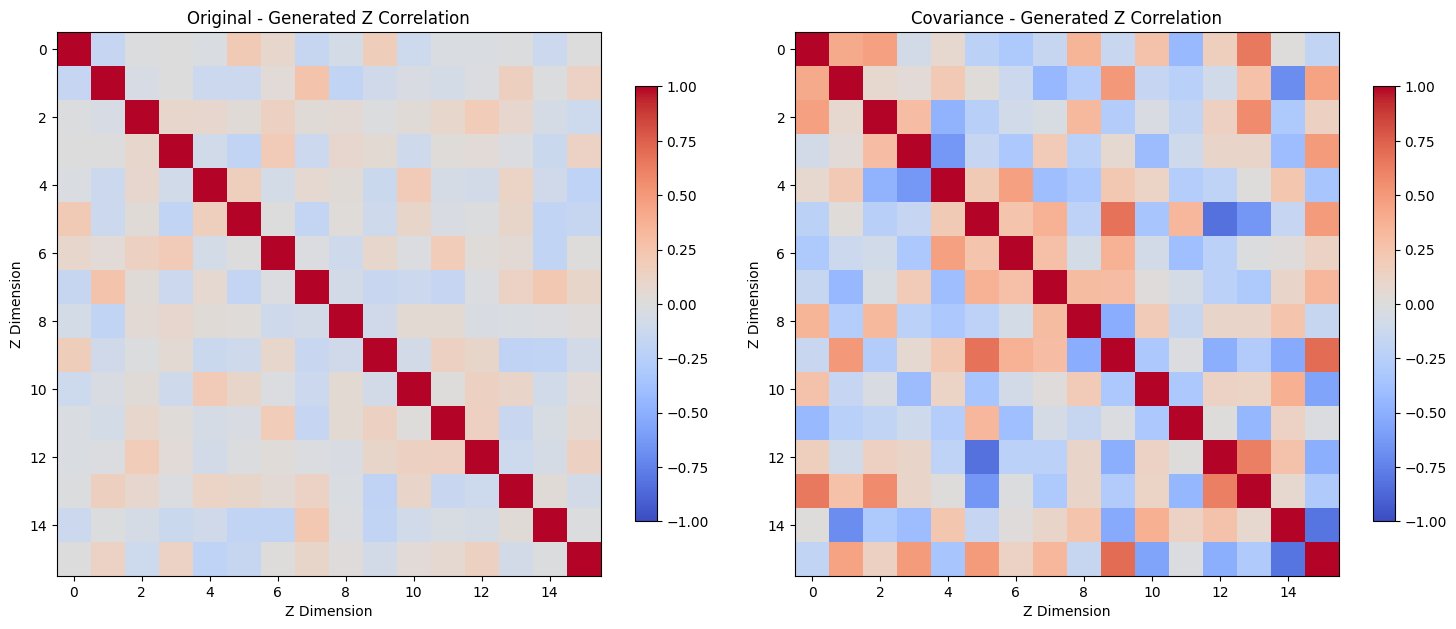


与训练集相关矩阵的Frobenius范数差异:
Original: 5.2726
Covariance: 1.7477


In [27]:
# 测试不同的采样方法并比较结果
N_samples = 100

print("正在测试不同的采样方法...")

# 方法1: 原始的独立采样（当前方法）
print("\n1. 原始独立采样:")
samples_continuous_orig, samples_categoricals_orig = model.sample(N_samples, temperature=0.1)

# 方法2: 协方差矩阵采样
print("2. 协方差矩阵采样:")
samples_continuous_cov, samples_categoricals_cov, z_samples_cov = sample_with_covariance(model, N_samples, temperature=0.1,standardize_variance=True)

# 比较生成的Z向量的相关性
methods = ['Original', 'Covariance']
z_samples_list = [
    torch.randn(N_samples, model.num_hidden).numpy(),  # 原始方法的等效Z
    z_samples_cov.cpu().numpy(),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()

for i, (method, z_samp) in enumerate(zip(methods, z_samples_list)):
    ax = axes[i]
    
    # 计算相关矩阵
    corr_matrix = np.corrcoef(z_samp.T)
    
    # 绘制热力图
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(f'{method} - Generated Z Correlation')
    ax.set_xlabel('Z Dimension')
    ax.set_ylabel('Z Dimension')
    
    # 添加颜色条
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig("Z_Sampling_Methods_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 计算与训练集相关矩阵的差异
train_corr = correlation_matrix
print("\n与训练集相关矩阵的Frobenius范数差异:")
for i, (method, z_samp) in enumerate(zip(methods, z_samples_list)):
    generated_corr = np.corrcoef(z_samp.T)
    diff = np.linalg.norm(train_corr - generated_corr, 'fro')
    print(f"{method}: {diff:.4f}")

In [42]:
# 生成两种不同的采样数据进行对比
N = int(3e4)  # Number of samples to generate

# 方法1: 原始独立采样
print("生成原始独立采样数据...")
model.eval()
with torch.no_grad():
    samples_continuous_orig, samples_categoricals_orig = model.sample(N, temperature=0.1)
    samples_categorical_indices_orig = [torch.argmax(c, dim=1) for c in samples_categoricals_orig]

# 重建原始独立采样数据
fake_data_columns_orig = []
continuous_counter = 0
categorical_counter = 0

for col_idx in range(34):
    if col_idx in categorical_col_indices:
        fake_data_columns_orig.append(samples_categorical_indices_orig[categorical_counter].unsqueeze(1))
        categorical_counter += 1
    else:
        fake_data_columns_orig.append(samples_continuous_orig[:, continuous_counter].unsqueeze(1))
        continuous_counter += 1

fake_data_tensor_orig = torch.cat(fake_data_columns_orig, dim=1)
fake_data_np_orig = fake_data_tensor_orig.cpu().numpy()

# 逆变换原始采样数据
fake_data_original_scale_orig = fake_data_np_orig.copy()
fake_data_original_scale_orig[:, continuous_col_indices] = scaler.inverse_transform(
    fake_data_np_orig[:, continuous_col_indices]
)
for idx in clip_col_indices:
    fake_data_original_scale_orig[:, idx] = np.power(10, np.clip(fake_data_original_scale_orig[:, idx], None, max_log10))
for idx in no_clip_col_indices:
    fake_data_original_scale_orig[:, idx] = np.power(10, fake_data_original_scale_orig[:, idx])

df_fake_original = pd.DataFrame(fake_data_original_scale_orig, columns=df.columns)

# 方法2: 相关性感知采样（Cholesky方法）
print("生成相关性感知采样数据...")
samples_continuous_chol, samples_categoricals_chol, z_samples_chol = sample_with_covariance(model, N, temperature=0.1, standardize_variance=False)
samples_categorical_indices_chol = [torch.argmax(c, dim=1) for c in samples_categoricals_chol]

# 重建相关性采样数据
fake_data_columns_chol = []
continuous_counter = 0
categorical_counter = 0

for col_idx in range(34):
    if col_idx in categorical_col_indices:
        fake_data_columns_chol.append(samples_categorical_indices_chol[categorical_counter].unsqueeze(1))
        categorical_counter += 1
    else:
        fake_data_columns_chol.append(samples_continuous_chol[:, continuous_counter].unsqueeze(1))
        continuous_counter += 1

fake_data_tensor_chol = torch.cat(fake_data_columns_chol, dim=1)
fake_data_np_chol = fake_data_tensor_chol.cpu().numpy()

# 逆变换相关性采样数据
fake_data_original_scale_chol = fake_data_np_chol.copy()
fake_data_original_scale_chol[:, continuous_col_indices] = scaler.inverse_transform(
    fake_data_np_chol[:, continuous_col_indices]
)
for idx in clip_col_indices:
    fake_data_original_scale_chol[:, idx] = np.power(10, np.clip(fake_data_original_scale_chol[:, idx], None, max_log10))
for idx in no_clip_col_indices:
    fake_data_original_scale_chol[:, idx] = np.power(10, fake_data_original_scale_chol[:, idx])

df_fake_correlated = pd.DataFrame(fake_data_original_scale_chol, columns=df.columns)

# 对特定列进行阈值处理
print("正在对特定列进行阈值处理...")

# 处理第11, 15, 17列 (0-based索引为10, 14, 16): 大于10000的设为65535
target_cols_10k = [10, 14, 16]  # 第11, 15, 17列
for col_idx in target_cols_10k:
    if col_idx < df_fake_correlated.shape[1]:
        col_name = df_fake_correlated.columns[col_idx]
        
        # 处理df_fake_correlated
        mask_corr = df_fake_correlated.iloc[:, col_idx] > 100
        count_corr = mask_corr.sum()
        df_fake_correlated.iloc[mask_corr, col_idx] = 65535
        
        # 处理df_original
        mask_orig = df_original.iloc[:, col_idx] > 100
        count_orig = mask_orig.sum()
        df_original.iloc[mask_orig, col_idx] = 65535
        
        print(f"  第{col_idx+1}列 ({col_name}): df_fake_correlated中{count_corr}个值 > 100 → 65535")
        print(f"  第{col_idx+1}列 ({col_name}): df_original中{count_orig}个值 > 100 → 65535")

# 处理第13列 (0-based索引为12): 大于1000的设为5000
target_col_1k = 12  # 第13列
if target_col_1k < df_fake_correlated.shape[1]:
    col_name = df_fake_correlated.columns[target_col_1k]
    
    # 处理df_fake_correlated
    mask_corr = df_fake_correlated.iloc[:, target_col_1k] > 150
    count_corr = mask_corr.sum()
    df_fake_correlated.iloc[mask_corr, target_col_1k] = 5000
    
    # 处理df_original
    mask_orig = df_original.iloc[:, target_col_1k] > 150
    count_orig = mask_orig.sum()
    df_original.iloc[mask_orig, target_col_1k] = 5000
    
    print(f"  第{target_col_1k+1}列 ({col_name}): df_fake_correlated中{count_corr}个值 > 150 → 5000")
    print(f"  第{target_col_1k+1}列 ({col_name}): df_original中{count_orig}个值 > 150 → 5000")

print("✅ 阈值处理完成!")

# 保存两种数据
df_fake_original.to_csv("generated_fake_data_original.csv", index=False)
df_fake_correlated.to_csv("generated_fake_data_correlated.csv", index=False)
print("已保存原始独立采样数据: generated_fake_data_original.csv")
print("已保存相关性感知采样数据: generated_fake_data_correlated.csv")

生成原始独立采样数据...
生成相关性感知采样数据...
📊 使用原始协方差矩阵
正在对特定列进行阈值处理...
  第11列 (R_t_c): df_fake_correlated中4087个值 > 100 → 65535
  第11列 (R_t_c): df_original中23个值 > 100 → 65535
  第15列 (R_m_c): df_fake_correlated中7271个值 > 100 → 65535
  第15列 (R_m_c): df_original中33个值 > 100 → 65535
  第17列 (R_a_c): df_fake_correlated中24477个值 > 100 → 65535
  第17列 (R_a_c): df_original中124个值 > 100 → 65535
  第13列 (R_p_c): df_fake_correlated中11994个值 > 150 → 5000
  第13列 (R_p_c): df_original中81个值 > 150 → 5000
✅ 阈值处理完成!
已保存原始独立采样数据: generated_fake_data_original.csv
已保存相关性感知采样数据: generated_fake_data_correlated.csv
已保存原始独立采样数据: generated_fake_data_original.csv
已保存相关性感知采样数据: generated_fake_data_correlated.csv


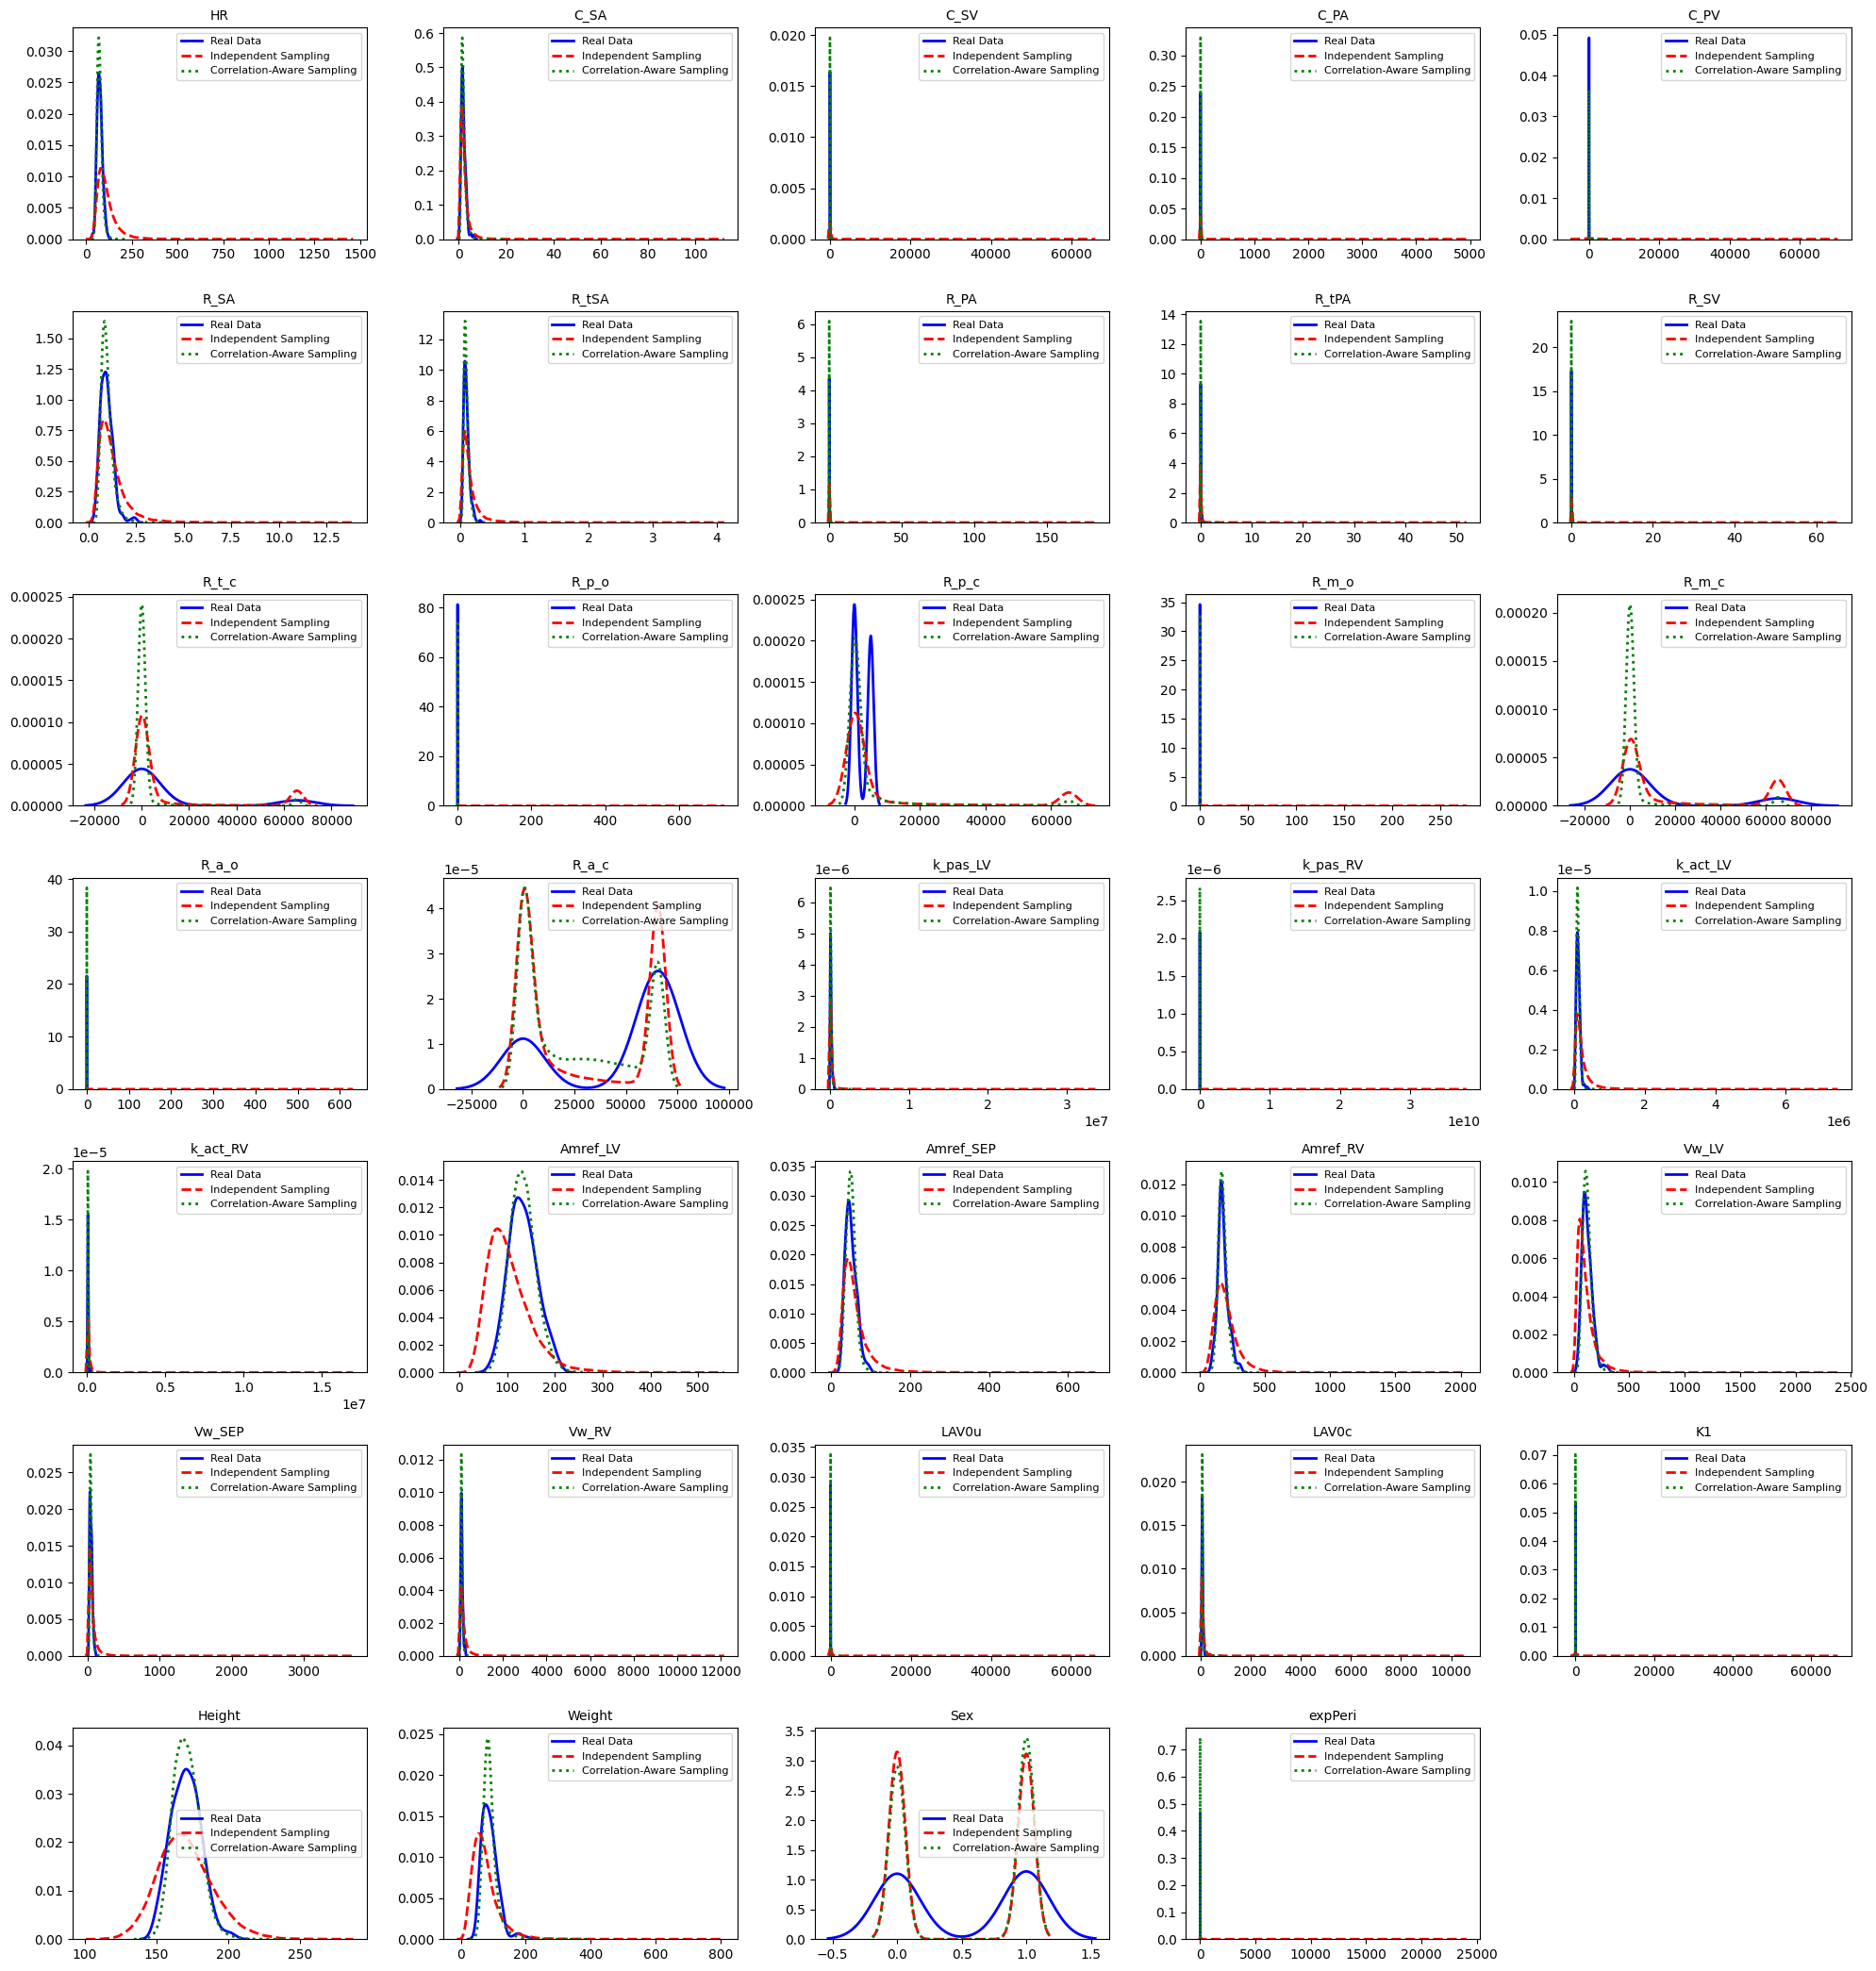

图例说明:
蓝色实线: 真实数据 (Real Data)
红色虚线: 原始独立采样 (Independent Sampling)
绿色点线: 相关性感知采样 (Correlation-Aware Sampling)


In [36]:
# 对比真实数据、原始独立采样和相关性感知采样
num_cols = 34
cols_to_plot = df_original.columns[:num_cols]

# Set up subplot grid
fig, axes = plt.subplots(nrows=num_cols // 5 + 1, ncols=5, figsize=(20, 3 * (num_cols // 5 + 1)))
axes = axes.flatten()

# Plot each feature's KDE for real data and both sampling methods
for i, col in enumerate(cols_to_plot):
    # 真实数据
    sns.kdeplot(df_original[col], ax=axes[i], label="Real Data", color="blue", linewidth=2)
    
    # 原始独立采样
    sns.kdeplot(df_fake_original[col], ax=axes[i], label="Independent Sampling", color="red", linestyle="--", linewidth=2)
    
    # 相关性感知采样
    sns.kdeplot(df_fake_correlated[col], ax=axes[i], label="Correlation-Aware Sampling", color="green", linestyle=":", linewidth=2)
    
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend(fontsize=8)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Sampling_Methods_Comparison_Updated.png", dpi=300, bbox_inches='tight')
plt.show()

print("图例说明:")
print("蓝色实线: 真实数据 (Real Data)")
print("红色虚线: 原始独立采样 (Independent Sampling)")
print("绿色点线: 相关性感知采样 (Correlation-Aware Sampling)")

In [43]:
# 读取数据
df_fake = pd.read_csv("generated_fake_data_correlated.csv")
input_data = df_fake.iloc[:, :34].to_numpy()

# 在输入数据前面加一列顺序排列的数字（1,2,3,4,5...）
index_column = np.arange(1, input_data.shape[0] + 1).reshape(-1, 1)
input_data = np.hstack([index_column, input_data])

# 启动 MATLAB 引擎
eng = matlab.engine.start_matlab()

labels = []
batch_size = 25
n = input_data.shape[0]

for i in range(0, n, batch_size):
    batch = input_data[i:i+batch_size]
    # 如果最后一批不满4行，自动补全为4行或让matlab函数能容忍
    if batch.shape[0] < batch_size:
        # 补齐最后一批，用0或其它合适的值填充
        pad = np.zeros((batch_size - batch.shape[0], batch.shape[1]))
        batch = np.vstack([batch, pad])
        matlab_input = matlab.double(batch.tolist())
        batch_labels = eng.simulate_batch_parallel(matlab_input)
        # 只保留真实长度部分
        labels.extend(batch_labels[:batch.shape[0] - pad.shape[0]])
        print(f"Processed samples: {min(i+batch_size, n)}/{n}")
    else:
        matlab_input = matlab.double(batch.tolist())
        batch_labels = eng.simulate_batch_parallel(matlab_input)
        labels.extend(batch_labels)
        print(f"Processed samples: {min(i+batch_size, n)}/{n}")

labels = np.array(labels).flatten()
df_fake['label'] = labels

eng.quit()

print(df_fake[['label']].head())
df_fake.to_csv("output_labeled.csv", index=False)
print("\n已保存所有结果到 output_labeled.csv")

MatlabExecutionError: 
  File C:\Program Files\MATLAB\R2025a\toolbox\parallel\cluster\cluster\parpool.m, line 132, in parpool

  File C:\Users\fenggu\University of Michigan Dropbox\Feng Gu\GitHub\Haolin_24Winter_Danlab\simulate_batch_parallel.m, line 8, in simulate_batch_parallel
Too many workers requested. The cluster "Processes" has the NumWorkers property set to a maximum of 6 workers but 10 workers were requested. Either request a number of workers less than NumWorkers, or increase the value of the NumWorkers property for the cluster (up to a maximum of 512 for the Local cluster).


In [52]:
# Conditional VAE (CVAE) 构建示例，label作为条件输入和重建目标

# Define the AutoEncoder model for CVAE
input_size = 35  # Total input features (continuous + categorical)

class CAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Set the number of hidden units
        self.num_hidden = 16
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size + 1, 256), # +1 for the label input
            nn.ReLU(),
            nn.Linear(256, self.num_hidden),
            nn.ReLU(),
        )
        
        # Decoder shared layers
        self.fc1 = nn.Linear(self.num_hidden + 1, 256) # +1 for the label input
        self.fc2 = nn.Linear(256, 128)
        
        # Separate heads
        self.fc_continuous = nn.Linear(128, continuous_dims)
        self.fc_categoricals = nn.ModuleList([
            nn.Linear(128, cat_dim) for cat_dim in categorical_dims
        ])
        
    def forward(self, x, y,temperature=0.5):
        # Encode
        x_cond = torch.cat([x, y], dim=1)
        encoded = self.encoder(x_cond)
        
        
        # Decode
        h = F.relu(self.fc1(encoded))
        h = F.relu(self.fc2(h))
        
        out_continuous = self.fc_continuous(h)
        
        out_categoricals = []
        for fc in self.fc_categoricals:
            logits = fc(h)
            out_categoricals.append(logits)
        return encoded, out_continuous, out_categoricals
    
class CVAE(CAutoEncoder):
    def __init__(self):
        super().__init__()
        # Add mu and log_var layers for reparameterization
        self.mu_layer = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var_layer = nn.Linear(self.num_hidden, self.num_hidden)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, y,temperature=0.5):
        # Encode
        x_cond = torch.cat([x, y], dim=1)
        encoded = self.encoder(x_cond)
        
        # Get mu and log_var
        mu = self.mu_layer(encoded)
        log_var = self.log_var_layer(encoded)
        
        # Sample latent vector z
        z = self.reparameterize(mu, log_var)
        z_cond = torch.cat([z, y], dim=1)

        # Decode
        h = F.relu(self.fc1(z_cond))
        h = F.relu(self.fc2(h))
        
        out_continuous = self.fc_continuous(h)
        
        out_categoricals = []
        for fc in self.fc_categoricals:
            logits = fc(h)
            out_categoricals.append(logits)    
        return z, out_continuous, out_categoricals, mu, log_var

    def sample(self, num_samples, y, temperature=0.5):
        with torch.no_grad():
            z = torch.randn(num_samples, self.num_hidden).to(device)
            y = y.view(-1, 1).float().to(device)  # Ensure shape and type

            z_cond = torch.cat([z, y], dim=1)
            h = F.relu(self.fc1(z_cond))
            h = F.relu(self.fc2(h))
            samples_continuous = self.fc_continuous(h)

            samples_categoricals = []
            for fc in self.fc_categoricals:
                logits = fc(h)
                soft_sample = F.gumbel_softmax(logits, tau=temperature, hard=True)
                samples_categoricals.append(soft_sample)

            return samples_continuous, samples_categoricals
        
    def vae_kl_loss(mu, log_var):
        return -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / mu.size(0)
    
    def autoencoder_loss(recon_continuous, true_continuous,
                     recon_categoricals, true_categoricals,
                     kl_loss, kl_weight=1e-6):
    # Continuous part
        mse_loss = F.mse_loss(recon_continuous, true_continuous, reduction='mean')
    
    # Categorical part
        cat_loss = 0
        for recon_cat, true_cat in zip(recon_categoricals, true_categoricals):
            # true_cat is [N] long tensor (category index)
            cat_loss += F.cross_entropy(recon_cat, true_cat, reduction='mean')
        cat_loss /= len(recon_categoricals)  # optional: balance contribution
    
        # Total
        total_loss = mse_loss + cat_loss + kl_weight * kl_loss
        return total_loss


In [53]:
torch.set_num_threads(4)

def train_cvae(X_continuous, X_categoricals,y_label, learning_rate=3e-4, num_epochs=5000, batch_size=16, kl_weight=3e-4):
    model = CVAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)

    train_dataset = torch.utils.data.TensorDataset(
        X_continuous,
        *X_categoricals,
        y_label  # 加上 label
    )


    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    recon_losses = []
    kl_losses = []
    total_losses = []

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        
        for batch in train_loader:
            batch_continuous = batch[0]  # first element
            batch_categoricals = list(batch[1:-1])  # the rest
            batch_label = batch[-1].float().view(-1, 1).to(device)  # 修正为 [N, 1] float 类型
            
            batch_continuous = batch_continuous.to(device)
            batch_categoricals = [b.to(device) for b in batch_categoricals]
            
            # 拼接输入：categorical 变量需要 unsqueeze(1) 再 float()
            input_batch = torch.cat(
                [batch_continuous] + [b.unsqueeze(1).float() for b in batch_categoricals],
                dim=1
            )
            # input_batch = torch.cat(
            # [batch_continuous] +
            # [b.unsqueeze(1).float() for b in batch_categoricals[:-1]] +  # 正常 one-hot 展开过的
            # [F.one_hot(b.squeeze(), num_classes=3).float() for b in batch_categoricals[-1:]],  # index → one-hot
            # dim=1
            # )


            encoded, recon_continuous, recon_categoricals, mu, log_var = model(input_batch, batch_label, temperature=0.5)

            # KL Divergence
            kl = vae_kl_loss(mu, log_var)

            # Loss
            loss = autoencoder_loss(
                recon_continuous, batch_continuous,
                recon_categoricals, batch_categoricals,
                kl_loss=kl, kl_weight=kl_weight
            )

            # 统计recon和kl
            mse_loss = F.mse_loss(recon_continuous, batch_continuous, reduction='mean')
            cat_loss = 0
            for recon_cat, true_cat in zip(recon_categoricals, batch_categoricals):
                cat_loss += F.cross_entropy(recon_cat, true_cat, reduction='mean')
            cat_loss /= len(recon_categoricals)
            recon_loss = mse_loss + cat_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * batch_continuous.size(0)
            total_recon += recon_loss.item() * batch_continuous.size(0)
            total_kl += kl.item() * batch_continuous.size(0)

        epoch_loss = total_loss / len(train_loader.dataset)
        epoch_recon = total_recon / len(train_loader.dataset)
        epoch_kl = total_kl / len(train_loader.dataset)
        total_losses.append(epoch_loss)
        recon_losses.append(epoch_recon)
        kl_losses.append(epoch_kl)
        print(f"Epoch {epoch+1}/{num_epochs} — Total: {epoch_loss:.4f} | Recon: {epoch_recon:.4f} | KL: {kl_weight * epoch_kl:.4f}")

        if epoch_loss < 1e-3:
            print("Early stopping.")
            break

    # 训练结束后返回各项loss
    return model, total_losses, recon_losses, kl_losses


In [33]:
# 读取 output_labeled.csv 并预处理，用所有数据训练CVAE，采样时指定label=1
df_labeled = pd.read_csv('output_labeled.csv')

# 只取前35列和label列
feature_cols = df_labeled.columns[:35].tolist()
label_col = 'label'

# 用所有数据训练
df_cvae = df_labeled.copy()

# 归一化和log变换（和前面一致）
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 连续和分类变量分离（和前面一致）
categorical_cols_cvae = []
continuous_cols_cvae = []
unique_threshold = 10
for col in feature_cols:
    n_unique = df_cvae[col].nunique(dropna=True)
    if n_unique <= unique_threshold:
        categorical_cols_cvae.append(col)
    else:
        continuous_cols_cvae.append(col)

# log变换连续变量
for col in continuous_cols_cvae:
    df_cvae[col] = df_cvae[col].apply(lambda x: np.log10(x) if pd.notnull(x) and x > 0 else np.nan)

# MinMax归一化连续变量
scaler_cvae = MinMaxScaler()
df_cvae[continuous_cols_cvae] = scaler_cvae.fit_transform(df_cvae[continuous_cols_cvae])

# 构造训练数据
X_cvae = torch.tensor(df_cvae[feature_cols].values, dtype=torch.float32)
y_cvae = torch.tensor(df_cvae[label_col].values, dtype=torch.float32).view(-1, 1)

In [54]:
X_continuous = X_cvae[:,continuous_col_indices]  # continuous features
X_categoricals = [
    X_cvae[:, col_idx].long() for col_idx in categorical_col_indices
]  # list of tensors, each of shape: [408]

# Now you can train
model, total_losses, recon_losses, kl_losses = train_cvae(X_continuous, X_categoricals, y_cvae)

Epoch 1/5000 — Total: 0.9870 | Recon: 0.9869 | KL: 0.0001
Epoch 2/5000 — Total: 0.9407 | Recon: 0.9406 | KL: 0.0001
Epoch 3/5000 — Total: 0.8893 | Recon: 0.8892 | KL: 0.0001
Epoch 4/5000 — Total: 0.8561 | Recon: 0.8560 | KL: 0.0001
Epoch 5/5000 — Total: 0.8190 | Recon: 0.8189 | KL: 0.0001
Epoch 6/5000 — Total: 0.7864 | Recon: 0.7862 | KL: 0.0001
Epoch 7/5000 — Total: 0.7822 | Recon: 0.7821 | KL: 0.0002
Epoch 8/5000 — Total: 0.7559 | Recon: 0.7557 | KL: 0.0002
Epoch 9/5000 — Total: 0.7512 | Recon: 0.7511 | KL: 0.0002
Epoch 10/5000 — Total: 0.7343 | Recon: 0.7341 | KL: 0.0002
Epoch 11/5000 — Total: 0.7450 | Recon: 0.7448 | KL: 0.0002
Epoch 12/5000 — Total: 0.7364 | Recon: 0.7363 | KL: 0.0002
Epoch 13/5000 — Total: 0.7354 | Recon: 0.7352 | KL: 0.0002
Epoch 14/5000 — Total: 0.7310 | Recon: 0.7308 | KL: 0.0002
Epoch 15/5000 — Total: 0.7168 | Recon: 0.7166 | KL: 0.0002
Epoch 16/5000 — Total: 0.7187 | Recon: 0.7185 | KL: 0.0002
Epoch 17/5000 — Total: 0.6987 | Recon: 0.6984 | KL: 0.0003
Epoch 

In [55]:
model.eval()
with torch.no_grad():
    N = int(1e2)  # Number of samples to generate
    label_value = 1  # 你想生成的标签
    y_label = torch.full((N, 1), label_value, dtype=torch.float32).to(device)
    samples_continuous, samples_categoricals = model.sample(N, y_label, temperature=0.5)

    # Step 1: Argmax for all categoricals
    samples_categorical_indices = [torch.argmax(c, dim=1) for c in samples_categoricals]

# Step 2: Rebuild the fake data column by column
fake_data_columns = []

# Counters
continuous_counter = 0
categorical_counter = 0

for col_idx in range(35):
    if col_idx in categorical_col_indices:
        # Take from categorical sampled indices
        fake_data_columns.append(samples_categorical_indices[categorical_counter].unsqueeze(1))
        categorical_counter += 1
    else:
        # Take from continuous sampled outputs
        fake_data_columns.append(samples_continuous[:, continuous_counter].unsqueeze(1))
        continuous_counter += 1

# Stack into full fake data
fake_data_tensor = torch.cat(fake_data_columns, dim=1)
fake_data_np = fake_data_tensor.cpu().numpy()

# Step 3: Inverse transform continuous columns only
fake_data_original_scale = fake_data_np.copy()

# Continuous cols inverse transform
fake_data_original_scale[:, continuous_col_indices] = scaler.inverse_transform(
    fake_data_np[:, continuous_col_indices]
)
for idx in clip_col_indices:
    fake_data_original_scale[:, idx] = np.power(10, np.clip(fake_data_original_scale[:, idx], None, max_log10))
for idx in no_clip_col_indices:
    fake_data_original_scale[:, idx] = np.power(10, fake_data_original_scale[:, idx])
# Step 5: Save
df_fake = pd.DataFrame(fake_data_original_scale, columns=df.columns)
df_fake.to_csv("generated_fake_data_3.csv", index=False)

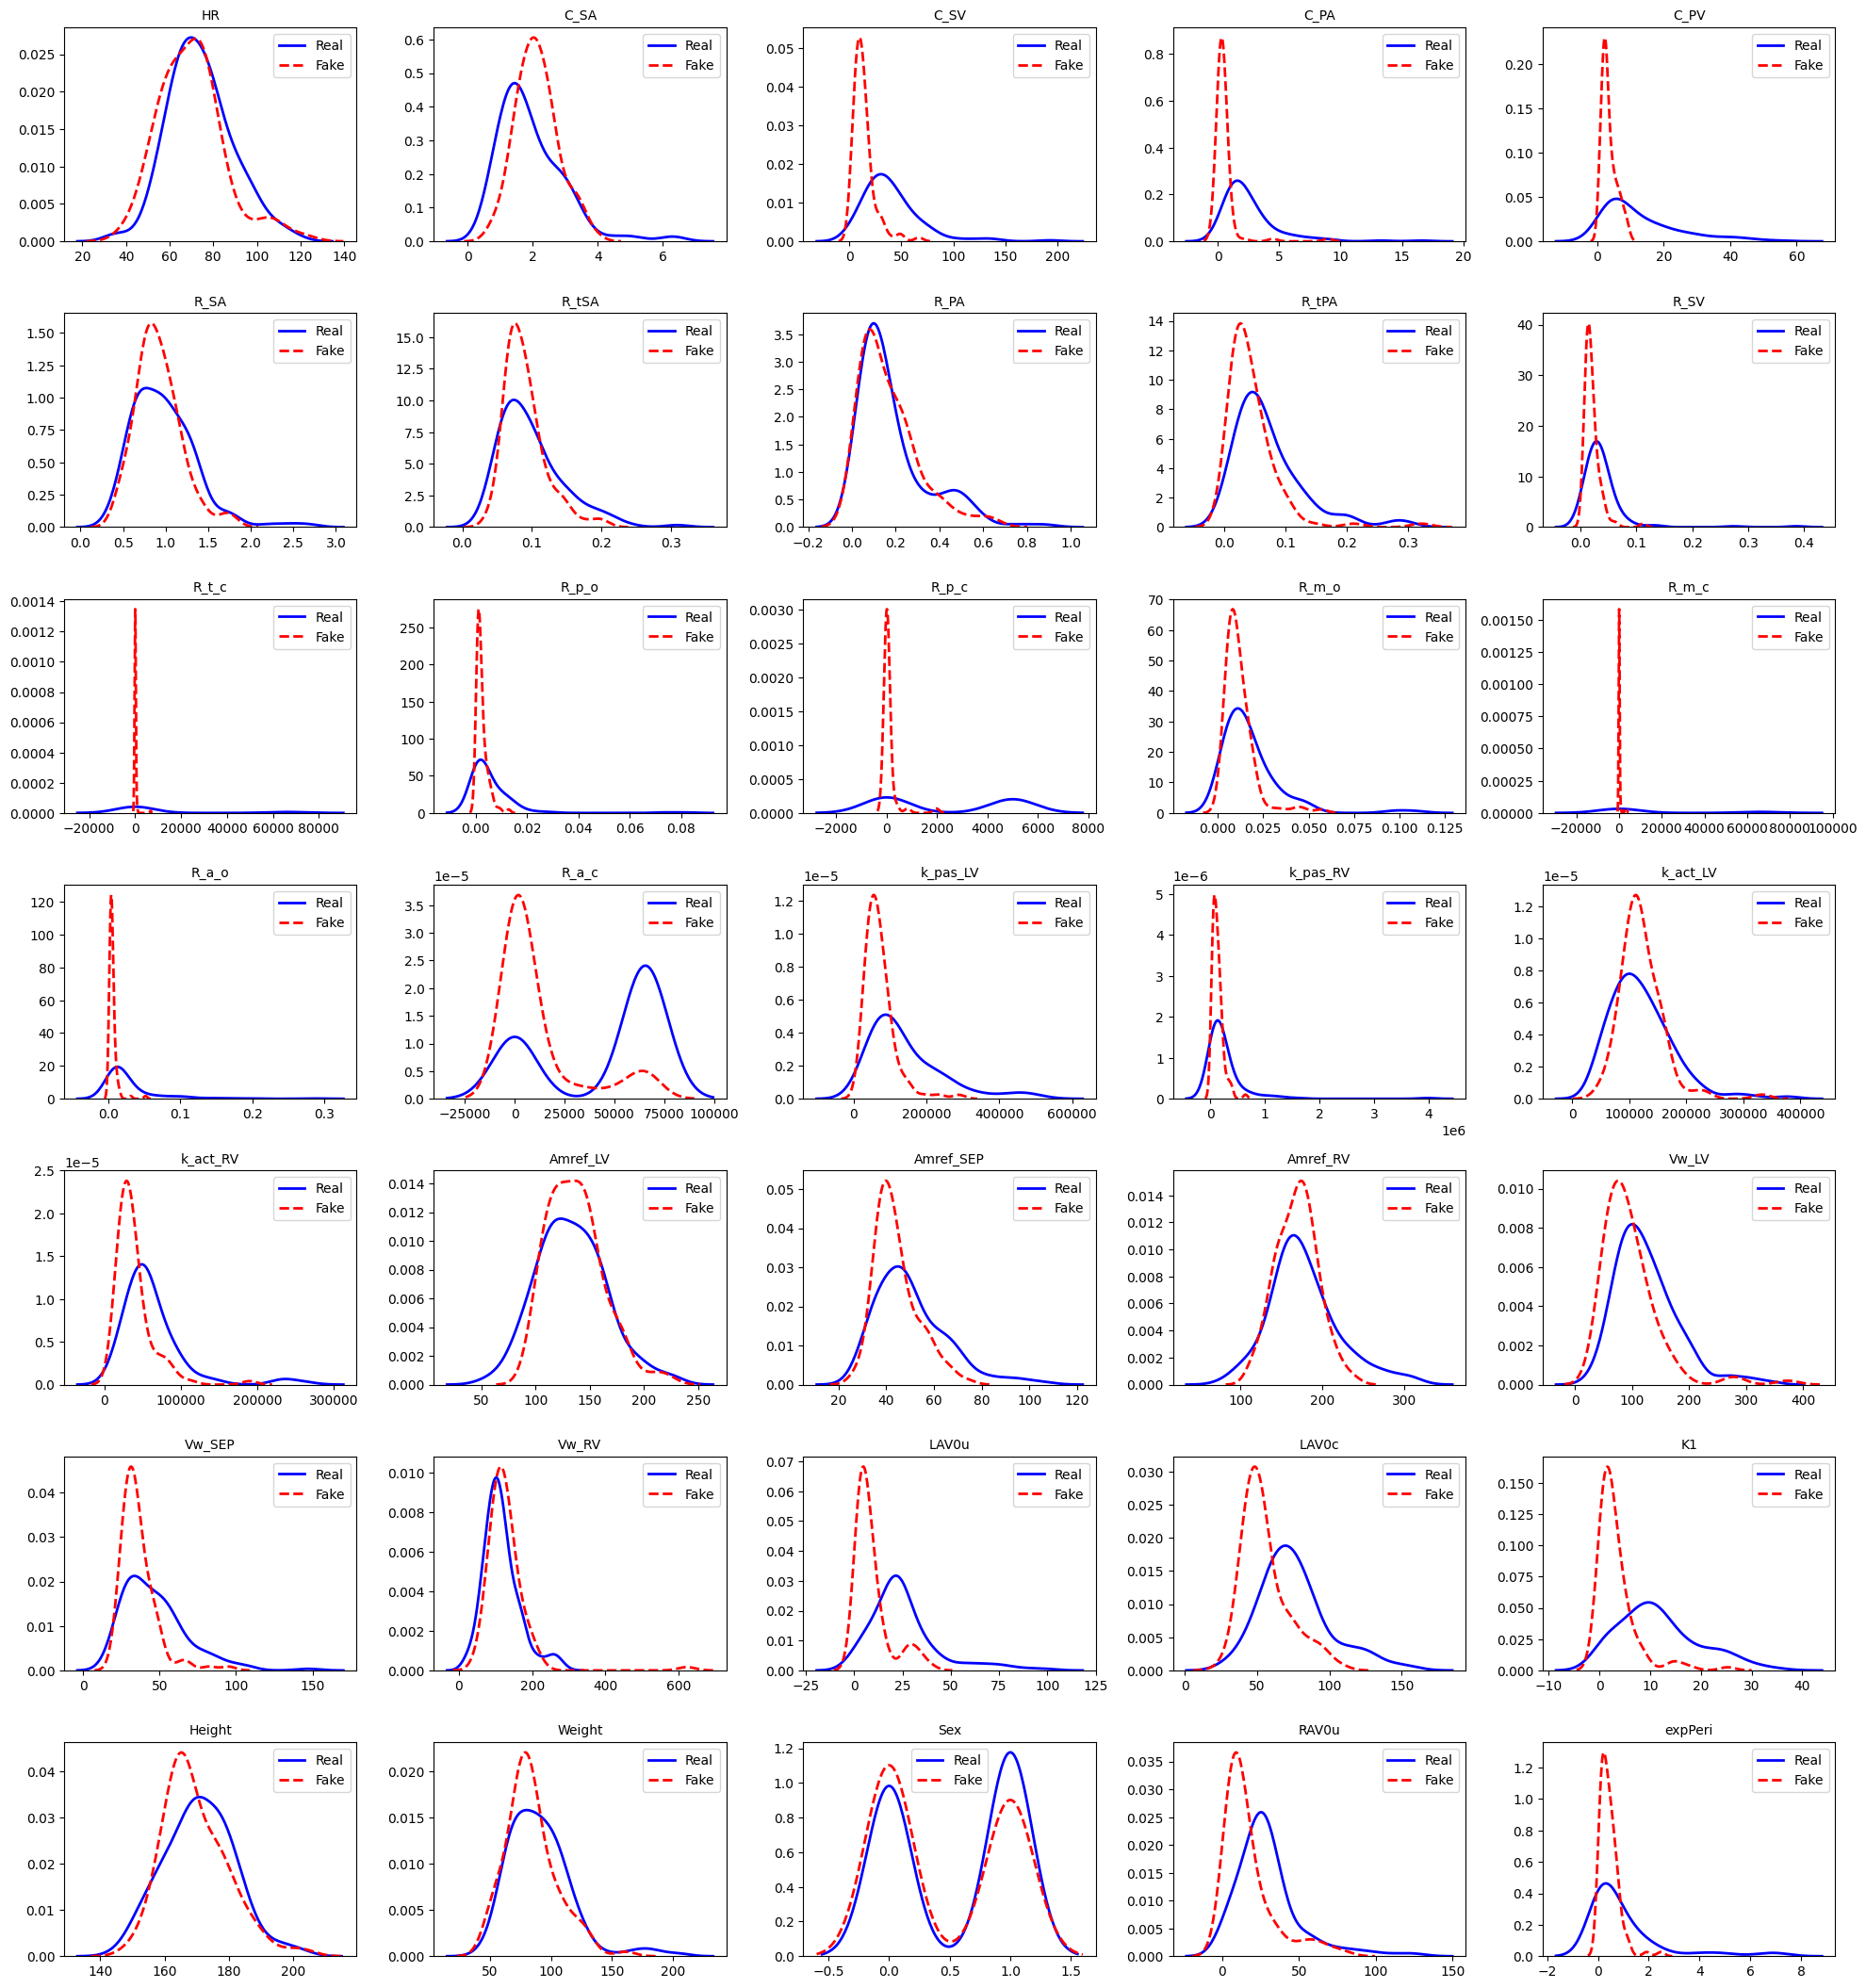

In [56]:
# Plot only the first 35 columns
num_cols = 35
cols_to_plot = df_original.columns[:num_cols]

# Set up subplot grid
fig, axes = plt.subplots(nrows=num_cols // 5 + 1, ncols=5, figsize=(20, 3 * (num_cols // 5 + 1)))
axes = axes.flatten()

# Plot each feature's KDE for real and fake
for i, col in enumerate(cols_to_plot):
    sns.kdeplot(df_original[col], ax=axes[i], label="Real", color="blue", linewidth=2)
    sns.kdeplot(df_fake[col], ax=axes[i], label="Fake", color="red", linestyle="--", linewidth=2)
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend()

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Fakedata_PDF_CC.png", dpi=300, bbox_inches='tight')
plt.show()

In [57]:
# 读取数据
df_fake = pd.read_csv("generated_fake_data_3.csv")
input_data = df_fake.iloc[:, :35].to_numpy()

# 启动 MATLAB 引擎
eng = matlab.engine.start_matlab()

labels = []
batch_size = 250
n = input_data.shape[0]

for i in range(0, n, batch_size):
    batch = input_data[i:i+batch_size]
    # 如果最后一批不满4行，自动补全为4行或让matlab函数能容忍
    if batch.shape[0] < batch_size:
        # 补齐最后一批，用0或其它合适的值填充
        pad = np.zeros((batch_size - batch.shape[0], batch.shape[1]))
        batch = np.vstack([batch, pad])
        matlab_input = matlab.double(batch.tolist())
        batch_labels = eng.simulate_batch_parallel(matlab_input)
        # 只保留真实长度部分
        labels.extend(batch_labels[:batch.shape[0] - pad.shape[0]])
        print(f"Processed samples: {min(i+batch_size, n)}/{n}")
    else:
        matlab_input = matlab.double(batch.tolist())
        batch_labels = eng.simulate_batch_parallel(matlab_input)
        labels.extend(batch_labels)
        print(f"Processed samples: {min(i+batch_size, n)}/{n}")

labels = np.array(labels).flatten()
df_fake['label'] = labels

eng.quit()

print(df_fake[['label']].head())
df_fake.to_csv("outputL_labeled.csv", index=False)
print("\n已保存所有结果到 outputL_labeled.csv")

Processed samples: 100/100
   label
0    0.0
1    0.0
2    0.0
3    1.0
4    0.0

已保存所有结果到 outputL_labeled.csv
